In [ ]:
!pip install openneuro-py nilearn nibabel scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 11.3 MB/s eta 0:00:00


In [ ]:
from openneuro import download

download(dataset="ds000003", target_dir="openneuro_data")


👋 Hello! This is openneuro-py 2026.3.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds000003 …


📁 Traversing directories for ds000003 : 0 entities [00:00, ? entities/s]

ERROR:sgqlc.endpoint.requests:log_error - https://openneuro.org/crn/graphql: 502 Server Error: Bad Gateway for url: https://openneuro.org/crn/graphql


🔄 Request timed out while retrieving metadata for 'sub-09/anat' (with tree='"66610357aed0c21aa145e6aa9cf41caf0afd3f3d"'), retrying (5 retries remain, backing off 0.5s) …
📥 Retrieving up to 87 files (5 concurrent downloads). 
✅ Finished downloading ds000003.
 
🧠 Please enjoy your brains.
 


In [ ]:
import os

mri_file = None

for root, dirs, files in os.walk("openneuro_data"):
    for file in files:
        if file.endswith(".nii") or file.endswith(".nii.gz"):
            mri_file = os.path.join(root, file)
            break
    if mri_file:
        break

print("MRI file found:", mri_file)

MRI file found: openneuro_data/sub-04/anat/sub-04_inplaneT2.nii.gz


In [ ]:
import nibabel as nib

img = nib.load(mri_file)

print("MRI shape:", img.shape)

MRI shape: (128, 128, 33)


In [ ]:
import numpy as np

data = img.get_fdata()

X = data.reshape(-1, data.shape[-1])

print(X.shape)

(16384, 33)


In [ ]:
from sklearn.cluster import KMeans

sample = X[:5000]

kmeans = KMeans(n_clusters=3)

kmeans.fit(sample)

labels = kmeans.labels_

print(labels[:10])

[0 0 0 0 0 0 0 0 0 0]


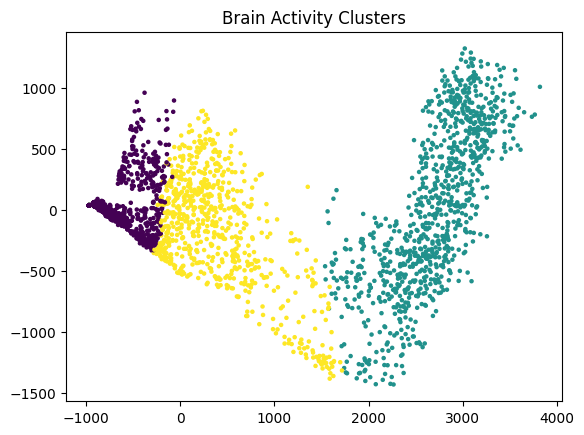

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_reduced = pca.fit_transform(sample)

plt.scatter(X_reduced[:,0], X_reduced[:,1], c=labels, s=5)

plt.title("Brain Activity Clusters")

plt.show()